In [10]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import run_extract, run_stack, read_galaxy_fits, run_measure, plotting, validation, multicat, analysis
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.io import apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo import starpsf

# Reading in output and stacking

In [11]:
#star_aegis_filename = './outputs_starpsf/galaxy_catc1488c_b7_fdea26_AEGIS_STAR_PSF_arcsec_biweight_image_bg57-63.fits'
star_aegis_filename = './outputs_starpsf/galaxy_catc1488c_b14_2dbbb7_AEGIS_STAR_PSF_arcsec_biweight_image_bg57-63.fits'
prod_aegis = read_galaxy_fits(star_aegis_filename)

#star_cosmos_filename = './outputs_starpsf/galaxy_catc1488c_b7_fdea26_COSMOS_STAR_PSF_arcsec_biweight_image_bg57-63.fits'
star_cosmos_filename = './outputs_starpsf/galaxy_catc1488c_b14_2dbbb7_COSMOS_STAR_PSF_arcsec_biweight_image_bg57-63.fits'
prod_cosmos = read_galaxy_fits(star_cosmos_filename)

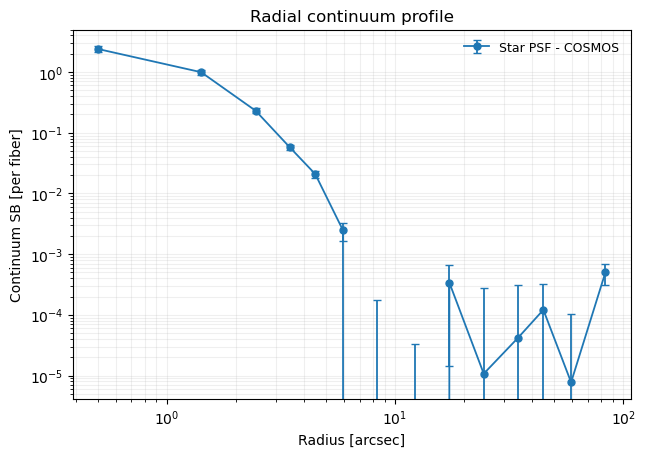

----------


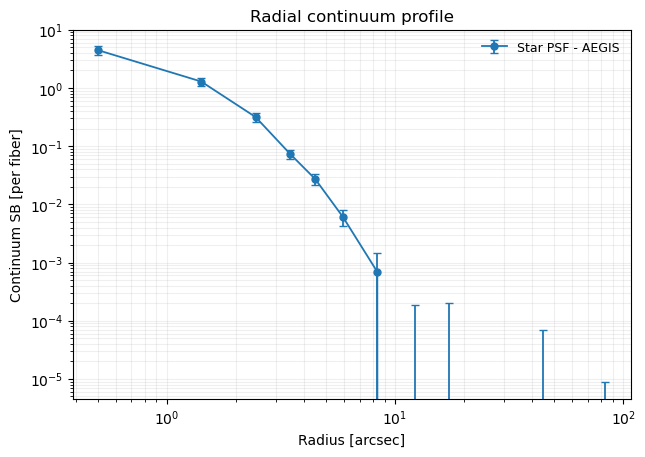

----------
combined 2 products -> 203 galaxies (origin in column 'SUBSET')


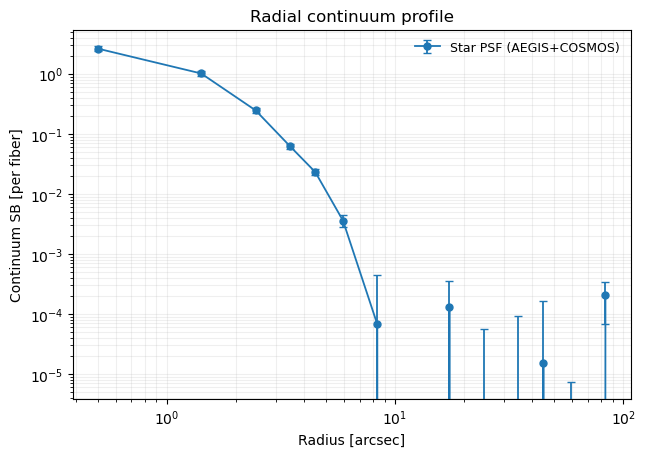

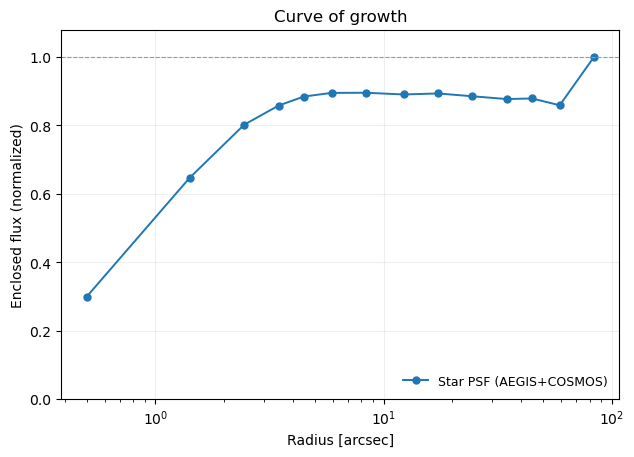

(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Curve of growth'}, xlabel='Radius [arcsec]', ylabel='Enclosed flux (normalized)'>)

In [12]:
# radial continuum profile -> plot
profile_cosmos = starpsf.radial_continuum_profile(prod_cosmos, band=(5000, 5200), combine="biweight")
starpsf.plot_radial_profile({"Star PSF - COSMOS": profile_cosmos}, bin_mode="arcsec")

print("----------")

# radial continuum profile -> plot
profile_aegis = starpsf.radial_continuum_profile(prod_aegis, band=(5000, 5200), combine="biweight")
starpsf.plot_radial_profile({"Star PSF - AEGIS": profile_aegis}, bin_mode="arcsec")

print("----------")

#Combines both to produce a unified PSF (but understand the field-to-field differences ARE real)
star_both = multicat.combine_products({"AEGIS": prod_aegis, "COSMOS": prod_cosmos})

profile_both = starpsf.radial_continuum_profile(star_both, band=(5000, 5200), combine="biweight")
cog_both     = starpsf.curve_of_growth(profile_both, area_weight="nfib")

starpsf.plot_radial_profile({"Star PSF (AEGIS+COSMOS)": profile_both}, bin_mode="arcsec")
starpsf.plot_curve_of_growth({"Star PSF (AEGIS+COSMOS)": cog_both}, bin_mode="arcsec")

# Comparison with Galaxies

In [14]:
gal_aegis_filename = './outputs/galaxy_catc1488c_b14_2dbbb7_AEGIS_MOSDEF_arcsec_biweight_image_bg57-63.fits'
gal_aegis = read_galaxy_fits(gal_aegis_filename)

gal_cosmos_filename = './outputs/galaxy_catc1488c_b14_2dbbb7_COSMOS_MOSDEF_arcsec_biweight_image_bg57-63.fits'
gal_cosmos = read_galaxy_fits(gal_cosmos_filename)

#Combines both to produce a unified PSF (but understand the field-to-field differences ARE real)
gal_prod = multicat.combine_products({"AEGIS": gal_aegis, "COSMOS": gal_cosmos})

combined 2 products -> 528 galaxies (origin in column 'SUBSET')


In [25]:
half_window = 3

cfg2 = replace(cfg, 
    field="BOTH",
    bins=[0, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 40, 50, 70, 100],
    bin_mode='arcsec',
    flux_unit='flux_arcsec2',
    catalog_path="catalogs/lya_halo_catalog_cuts/ALL_haoiii_sn5_mosdef_catalog.txt",
    n_bootstrap=1000,
    line_window = [1215.67-half_window, 1215.67+half_window],
    rest_density=True,
    rest_wave_min=1000, rest_wave_max=1700)   #<-- needed for the full LIS suite

stacks_gal = build_stacks(cfg2, gal_prod, keep_cube=True)

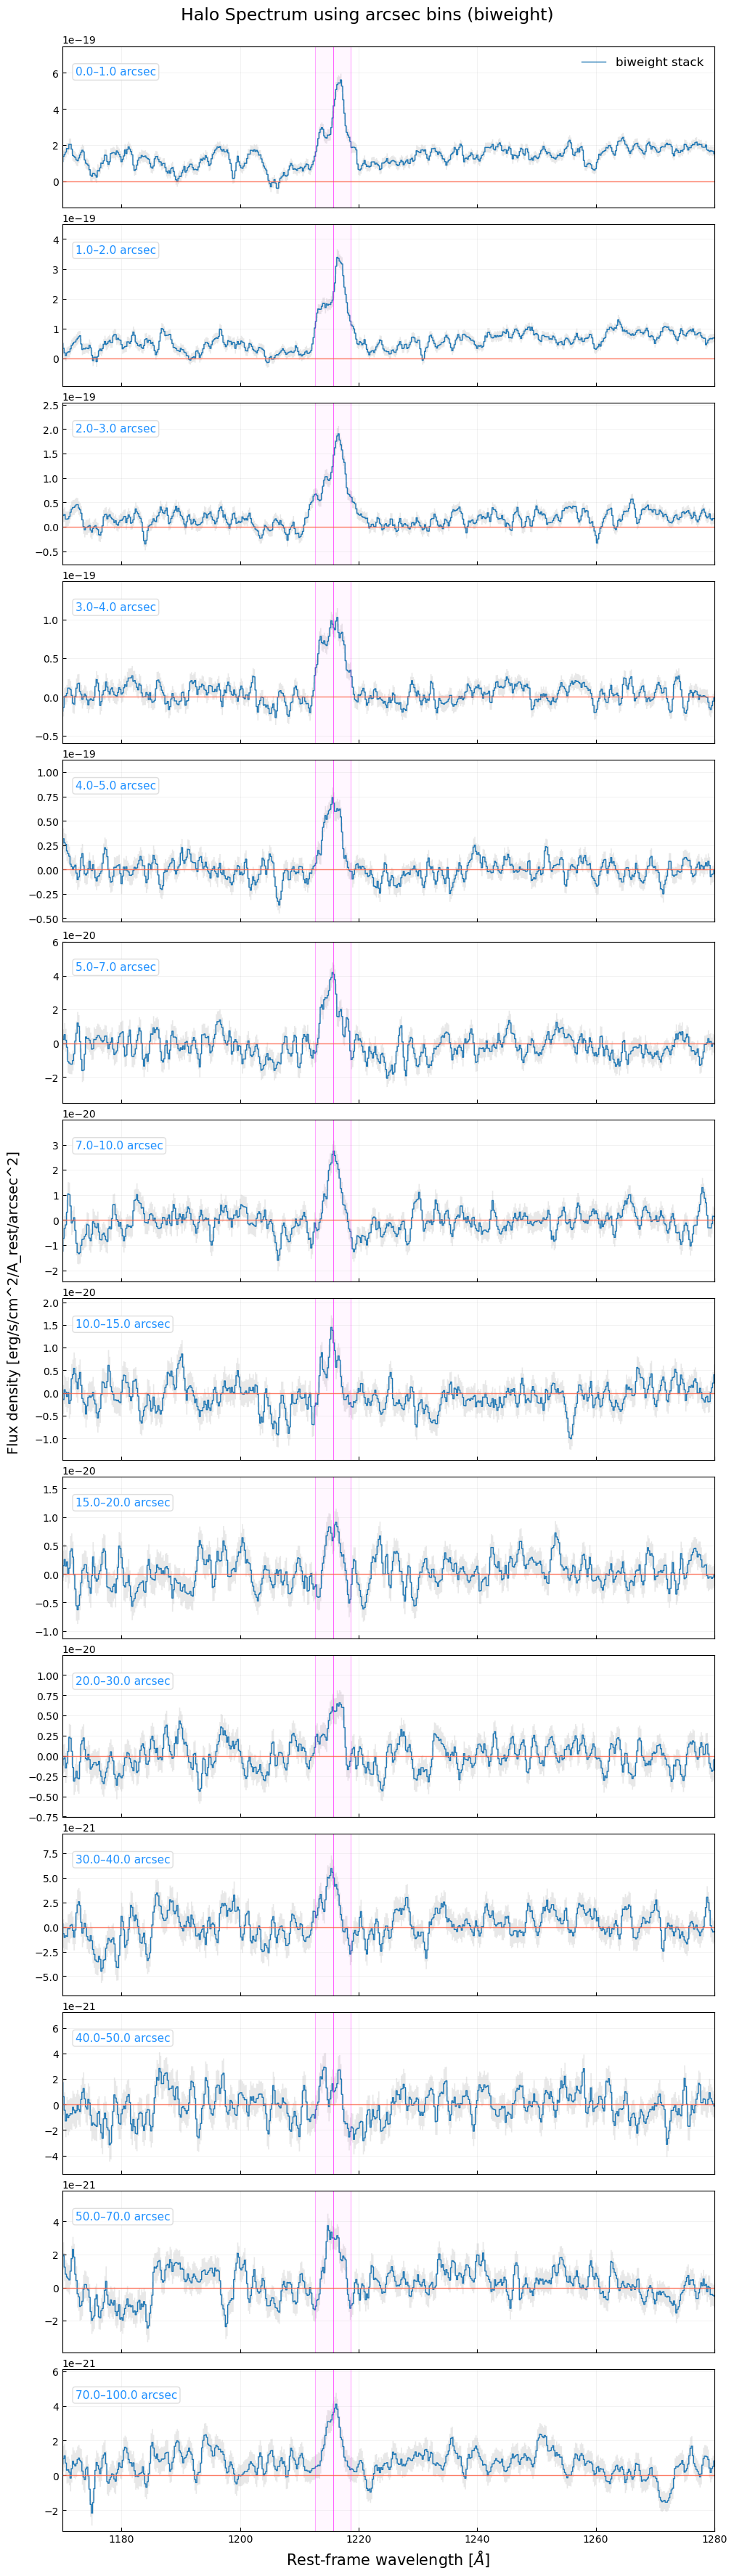

(<Figure size 1000x3500 with 14 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>],
       dtype=object))

In [24]:
plotting.plot_stack_panels(stacks_gal, 
    method="biweight",
    distance_type="arcsec",
    title=None,
    xlim=(1170, 1280),
    lya_window=3,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

In [16]:
wave  = stacks_gal["rest_wave"]
stack = stacks_gal["stacks"]["biweight"]["flux"]      # (nrad, nwave), erg/s/cm2/A_rest/arcsec2
bounds = tuple(cfg2.line_window)
for r in range(stack.shape[0]):
    res = integrated_line_flux(wave, stack[r], bounds=bounds)
    print(r, res["flux_integral"])    # erg/s/cm2/arcsec2  <-- compare THIS to 1e-19/1e-20

0 1.3147455766722117e-18
1 1.0495078159825711e-18
2 6.902782830565834e-19
3 4.089188302729744e-19
4 2.4398309177171715e-19
5 1.2790961373541817e-19
6 4.243584813559538e-20
7 2.8087292361065716e-20
8 1.1892517988408487e-20
9 2.255216157406543e-20
10 1.1647740745666702e-20
11 -5.000769537009775e-22
12 3.82302324967522e-21
13 5.056933360674145e-21


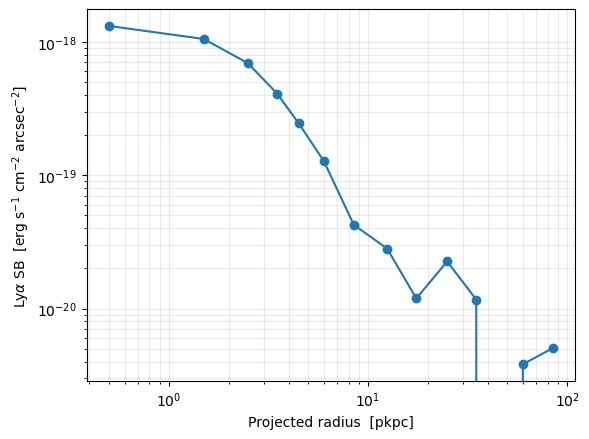

In [31]:
# Surface brightness: one value per annular bin
sb = np.array([
    1.3147455766722117e-18, 1.0495078159825711e-18, 6.902782830565834e-19,
    4.089188302729744e-19, 2.4398309177171715e-19, 1.2790961373541817e-19,
    4.243584813559538e-20, 2.8087292361065716e-20, 1.1892517988408487e-20,
    2.255216157406543e-20, 1.1647740745666702e-20, -5.000769537009775e-22,
    3.82302324967522e-21, 5.056933360674145e-21])

bins = np.array([0, 1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 40, 50, 70, 100])
r = 0.5 * (bins[:-1] + bins[1:])          # radius = bin center, one per annulus
assert len(r) == len(sb) == 14

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(r, sb, 'o-', lw=1.5, ms=6)
ax.set_yscale('log')                       # standard for SB profiles
ax.set_xlabel('Projected radius  [pkpc]')  # change to arcsec/pix if that's your unit
ax.set_xscale('log')
ax.set_ylabel(r'Ly$\alpha$ SB  [erg s$^{-1}$ cm$^{-2}$ arcsec$^{-2}$]')
ax.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.show()

# Bootstrap and measure Lya compared to PSF

In [26]:
boot = analysis.run_measurement_suite(cfg2, stacks_gal)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-1: v=+113.0  σ=343.0  skew=-0.553
  1-2: v=+74.3  σ=372.4  skew=-0.393
  2-3: v=+83.0  σ=352.9  skew=-0.390
  3-4: v=-14.7  σ=368.4  skew=-0.020
  4-5: v=-35.3  σ=290.3  skew=-0.133
  5-7: v=-26.9  σ=313.9  skew=+0.321
  7-10: v=+37.0  σ=231.2  skew=+0.012
  10-15: v=-84.1  σ=258.0  skew=-0.154
  15-20: v=+14.8  σ=218.6  skew=+0.076
  20-30: v=+18.5  σ=319.1  skew=-0.568
  30-40: v=-122.3  σ=249.7  skew=-0.363
  40-50: v=-114.7  σ=310.2  skew=+0.125
  50-70: v=+35.4  σ=246.7  skew=+0.185
  70-100: v=+16.3  σ=216.5  skew=-0.145


In [27]:
gal_profile = boot['total_flux_med']
#boot['total_flux_fid']

In [28]:
boot['r_mid'] = profile_aegis['r_mid']
boot['sb'] = boot['total_flux_med']
boot['sb_err'] = (boot['total_flux_hi']-boot['total_flux_lo'])/2

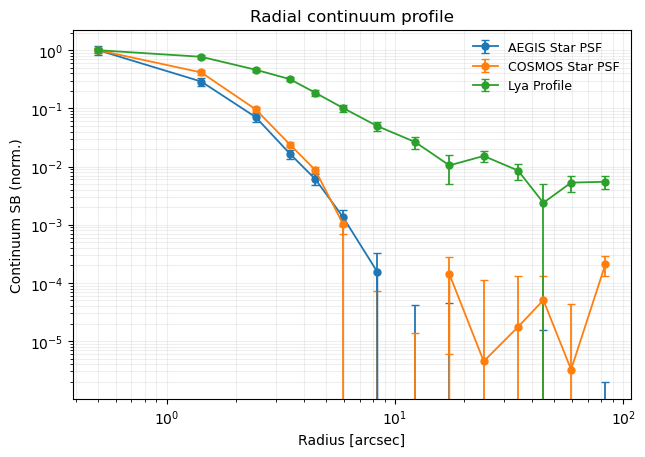

(<Figure size 720x480 with 1 Axes>,
 <Axes: title={'center': 'Radial continuum profile'}, xlabel='Radius [arcsec]', ylabel='Continuum SB (norm.)'>)

In [29]:
starpsf.plot_radial_profile({"AEGIS Star PSF": profile_aegis, "COSMOS Star PSF": profile_cosmos, "Lya Profile": boot},
    bin_mode="arcsec",
    normalize=True,
    save_fig=True)

In [8]:
# Bootstrap the LIS lines: per-line S/N, rank, keep the strongest 5
lis_bs = starpsf.bootstrap_line_profiles(cfg2, stacks_gal, product=gal_prod,
    nboot=300, 
    rank_by="central",
    select_top=5,   # or use min_sn=3.0 instead
    verbose=True)

LIS line bootstrap:   0%|          | 0/300 [00:00<?, ?it/s]


bootstrapped LIS line profiles (method=biweight, nboot=300, ranked by sn_central):
  line         central S/N  profile S/N   kept?
  O I+Si II 1303        5.19         8.11    keep
  Si II* 1336         3.13         4.75    keep
  C II 1335           3.04         4.45    keep
  Si II 1527          2.06         4.25    keep
  Si II 1260          1.72         3.73    keep
  Fe II 1608          1.36         5.41    drop
  Si II* 1265         1.19         4.60    drop
  [off rest grid, skipped: Al II 1671]


In [9]:
print('done')

done


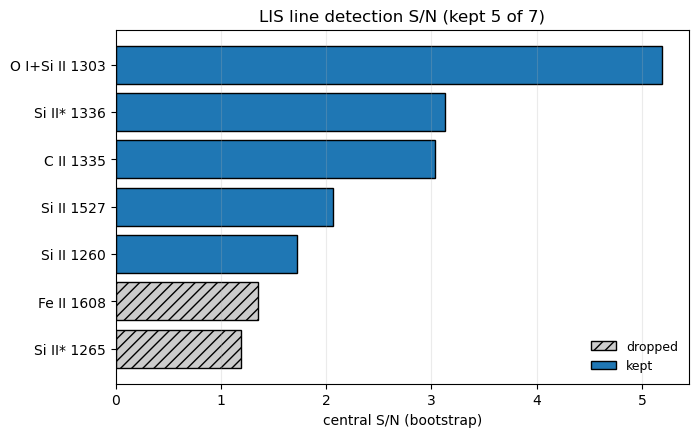

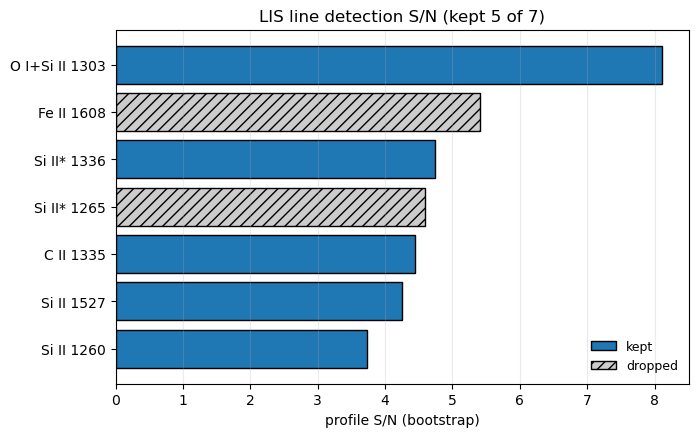

(<Figure size 740x460 with 1 Axes>,
 <Axes: title={'center': 'LIS line detection S/N (kept 5 of 7)'}, xlabel='profile S/N (bootstrap)'>)

In [10]:
# Per-line detection S/N, showing where your cut landed
starpsf.plot_line_sn(lis_bs, rank_by='central')
starpsf.plot_line_sn(lis_bs, rank_by='profile')

In [11]:
def plot_line_sn_radial(lis_bs, lya_bs=None, only_selected=False,
                        guides=(1, 2, 3), figsize=(8.2, 5.2)):
    """Signed S/N (= flux/flux_err) per radial bin, one curve per LIS line.
    Sign kept: absorption lines run negative, emission positive. Pass lya_bs
    (a bootstrap_line_profiles result on Lyα) to overlay Lyα for comparison."""
    r = np.asarray(lis_bs["r_mid"], float)
    sel = set(lis_bs["selected"])
    items = list(lis_bs["per_line"].items())
    if only_selected:
        items = [(k, d) for k, d in items if k in sel]
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(items), 1)))

    fig, ax = plt.subplots(figsize=figsize)
    for (k, d), c in zip(items, colors):
        sn = np.asarray(d["flux"], float) / np.asarray(d["flux_err"], float)
        kept = k in sel
        ax.plot(r, sn, "o-" if kept else "o--", color=c, lw=1.8 if kept else 1.0,
                ms=5, alpha=1.0 if kept else 0.45,
                label=f"{d['name']} {d['lam']:.0f}" + ("" if kept else " (dropped)"))

    # optional Lyα overlay (apples-to-apples, the line you actually care about)
    if lya_bs is not None:
        d = next(iter(lya_bs["per_line"].values()))
        sn = np.asarray(d["flux"], float) / np.asarray(d["flux_err"], float)
        ax.plot(r, sn, "D-", color="black", lw=2.4, ms=7, zorder=10, label="Lyα")

    ax.axhline(0, color="0.5", lw=1)
    for g in guides:
        for s in (+g, -g):
            ax.axhline(s, color="0.7", ls=":", lw=0.8)
        ax.text(r[-1], g, f"+{g}σ", fontsize=7.5, color="0.5", va="bottom", ha="right")
        ax.text(r[-1], -g, f"−{g}σ", fontsize=7.5, color="0.5", va="top", ha="right")
    ax.set_xscale("log")
    ax.set_xlabel("Radius [arcsec]")
    ax.set_ylabel("Signed S/N  (flux / bootstrap error)")
    ax.set_title("Per-line significance vs radius (sign kept)")
    ax.legend(frameon=False, fontsize=8, ncol=2, loc="best")
    ax.grid(alpha=0.2, which="both")
    plt.show()
    return fig, ax

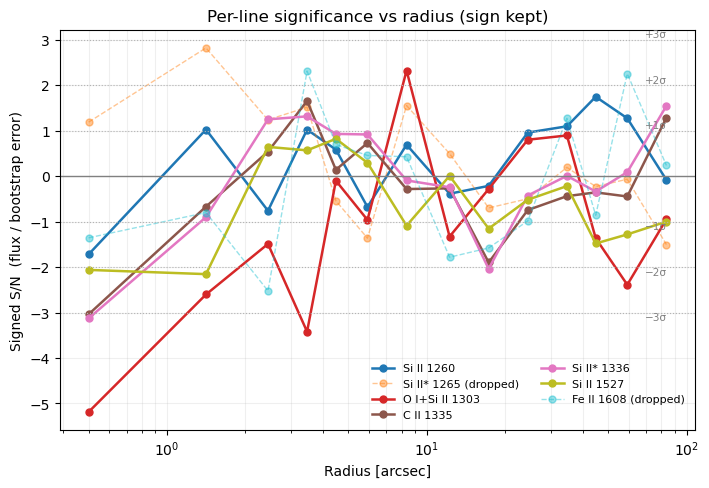

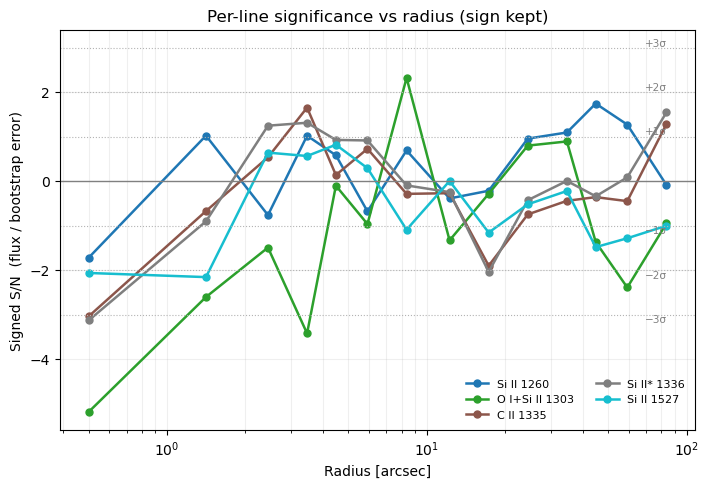

(<Figure size 820x520 with 1 Axes>,
 <Axes: title={'center': 'Per-line significance vs radius (sign kept)'}, xlabel='Radius [arcsec]', ylabel='Signed S/N  (flux / bootstrap error)'>)

In [12]:
plot_line_sn_radial(lis_bs)                       # all LIS lines
plot_line_sn_radial(lis_bs, only_selected=True)   # just the kept 5

In [13]:
# The primary overlay
psf = starpsf.psf_profiles_for_lines(star_both, z_obs=stacks_gal["z_median"],
                                     band_halfwidth_A=30.0)
lya = starpsf.measure_line_profiles(cfg2, stacks_gal, product=gal_prod,
                                    lines=[("Lyα", cfg2.LYA_REST, "em")])

PSF sampled at z_obs=2.30815 for 8 lines (±30 Å observed-frame bands).
line profiles (method=biweight, ±4.0 Å windows, 1 lines):
  Lyα       1215.67  norm profile = [ 1.    0.79  0.52  0.31  0.18  0.1   0.04  0.02  0.01  0.02  0.01 -0.
  0.    0.  ]


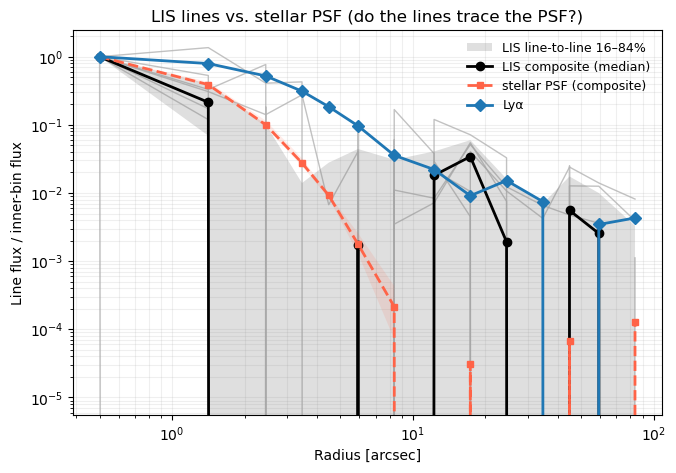

(<Figure size 760x500 with 1 Axes>,
 <Axes: title={'center': 'LIS lines vs. stellar PSF (do the lines trace the PSF?)'}, xlabel='Radius [arcsec]', ylabel='Line flux / inner-bin flux'>)

In [14]:
starpsf.plot_line_profiles(lis_bs, psf=psf, lya_result=lya,
    logy=True)

# Previous Method - No Bootstrap

In [7]:
# --- LIS lines on the galaxies, measured EXACTLY as Lya ---
lis = starpsf.measure_line_profiles(cfg2, stacks_gal, product=gal_prod)

# --- the stellar PSF each line lands on, at THIS sample's redshift ---
# uses prod_aegis (or prod_cosmos, or a combined "BOTH" star product)
psf = starpsf.psf_profiles_for_lines(star_both,
                                     z_obs=stacks_gal["z_median"],
                                     band_halfwidth_A=30.0)

# --- Lya in the identical representation, for the punchline ---
lya = starpsf.measure_line_profiles(cfg2, stacks_gal, product=gal_prod,
                                    lines=[("Lyα", cfg2.LYA_REST, "em")])

line profiles (method=biweight, ±4.0 Å windows, 7 lines):
  Si II     1260.42  norm profile = [ 1.   -0.43  0.03 -0.   -0.01 -0.02 -0.01]
  Si II*    1264.74  norm profile = [ 1.    2.56  0.2   0.    0.07  0.01 -0.05]
  O I+Si II 1303.27  norm profile = [ 1.    0.33  0.13 -0.05  0.02 -0.    0.01]
  C II      1334.53  norm profile = [ 1.    0.07 -0.11 -0.01  0.02  0.01 -0.  ]
  Si II*    1335.71  norm profile = [ 1.    0.17 -0.19 -0.01  0.02  0.01 -0.  ]
  Si II     1526.71  norm profile = [ 1.    0.52 -0.03  0.04  0.02  0.02  0.01]
  Fe II     1608.45  norm profile = [ 1.    0.23  0.08 -0.02  0.07  0.   -0.02]
  [skipped, off the rest grid: Al II 1671; widen rest_wave_min/max and rebuild stacks]
PSF sampled at z_obs=2.312 for 8 lines (±30 Å observed-frame bands).
line profiles (method=biweight, ±4.0 Å windows, 1 lines):
  Lyα       1215.67  norm profile = [1.   0.78 0.26 0.06 0.02 0.01 0.  ]


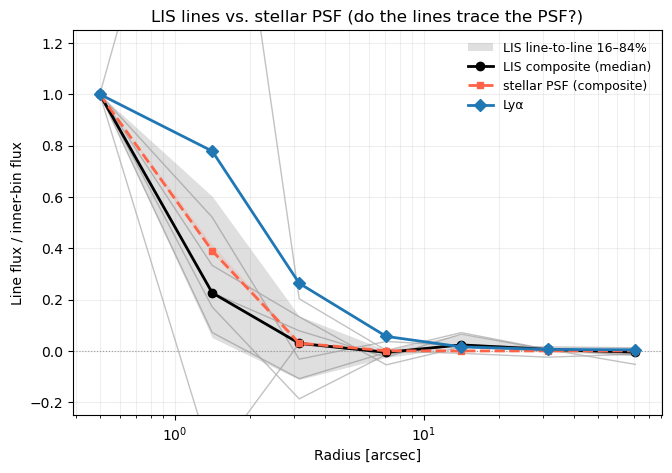

(<Figure size 760x500 with 1 Axes>,
 <Axes: title={'center': 'LIS lines vs. stellar PSF (do the lines trace the PSF?)'}, xlabel='Radius [arcsec]', ylabel='Line flux / inner-bin flux'>)

In [8]:
starpsf.plot_line_profiles(lis, psf=psf, lya_result=lya)